## PCA Assignment
#### PCA
Task 1: Exploratory Data Analysis (EDA):
1.	Load the dataset and perform basic data exploration.
2.	Examine the distribution of features using histograms, box plots, or density plots.
3.	Investigate correlations between features to understand relationships within the data.
Task 2: Dimensionality Reduction with PCA:
1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.
2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.
3.	Transform the original dataset into the principal components.
Task 3: Clustering with Original Data:
1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.
2.	Visualize the clustering results using appropriate plots.
3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.
Task 4: Clustering with PCA Data:
1.	Apply the same clustering algorithm to the PCA-transformed dataset.
2.	Visualize the clustering results obtained from PCA-transformed data.
3.	Compare the clustering results from PCA-transformed data with those from the original dataset.
Task 5: Comparison and Analysis:
1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.
2.	Discuss any similarities or differences observed in the clustering results.
3.	Reflect on the impact of dimensionality reduction on clustering performance.
4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.
Task 6: Conclusion and Insights

1.	Summarize the key findings and insights from the assignment.
2.	Discuss the practical implications of using PCA and clustering in data analysis.
3.	Provide recommendations for when to use each technique based on the analysis conducted.


In [2]:
# Step 1: Load the dataset and perform basic data exploration
import pandas as pd

# Load the dataset
df = pd.read_csv('wine.csv')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
df.head()

# Get basic information about the dataset
print("\nDataset information:")
df.info()

# Get summary statistics of the dataset
print("\nSummary statistics:")
df.describe()

# Check for missing values
print("\nMissing values in the dataset:")
df.isnull().sum()

First 5 rows of the dataset:

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB

Summary statistics:

Missing values in the dataset:


Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity         0
Magnesium          0
Phenols            0
Flavanoids         0
Nonflavanoids      0
Proanthocyanins    0
Color              0
Hue                0
Dilution           0
Proline            0
dtype: int64

In [3]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


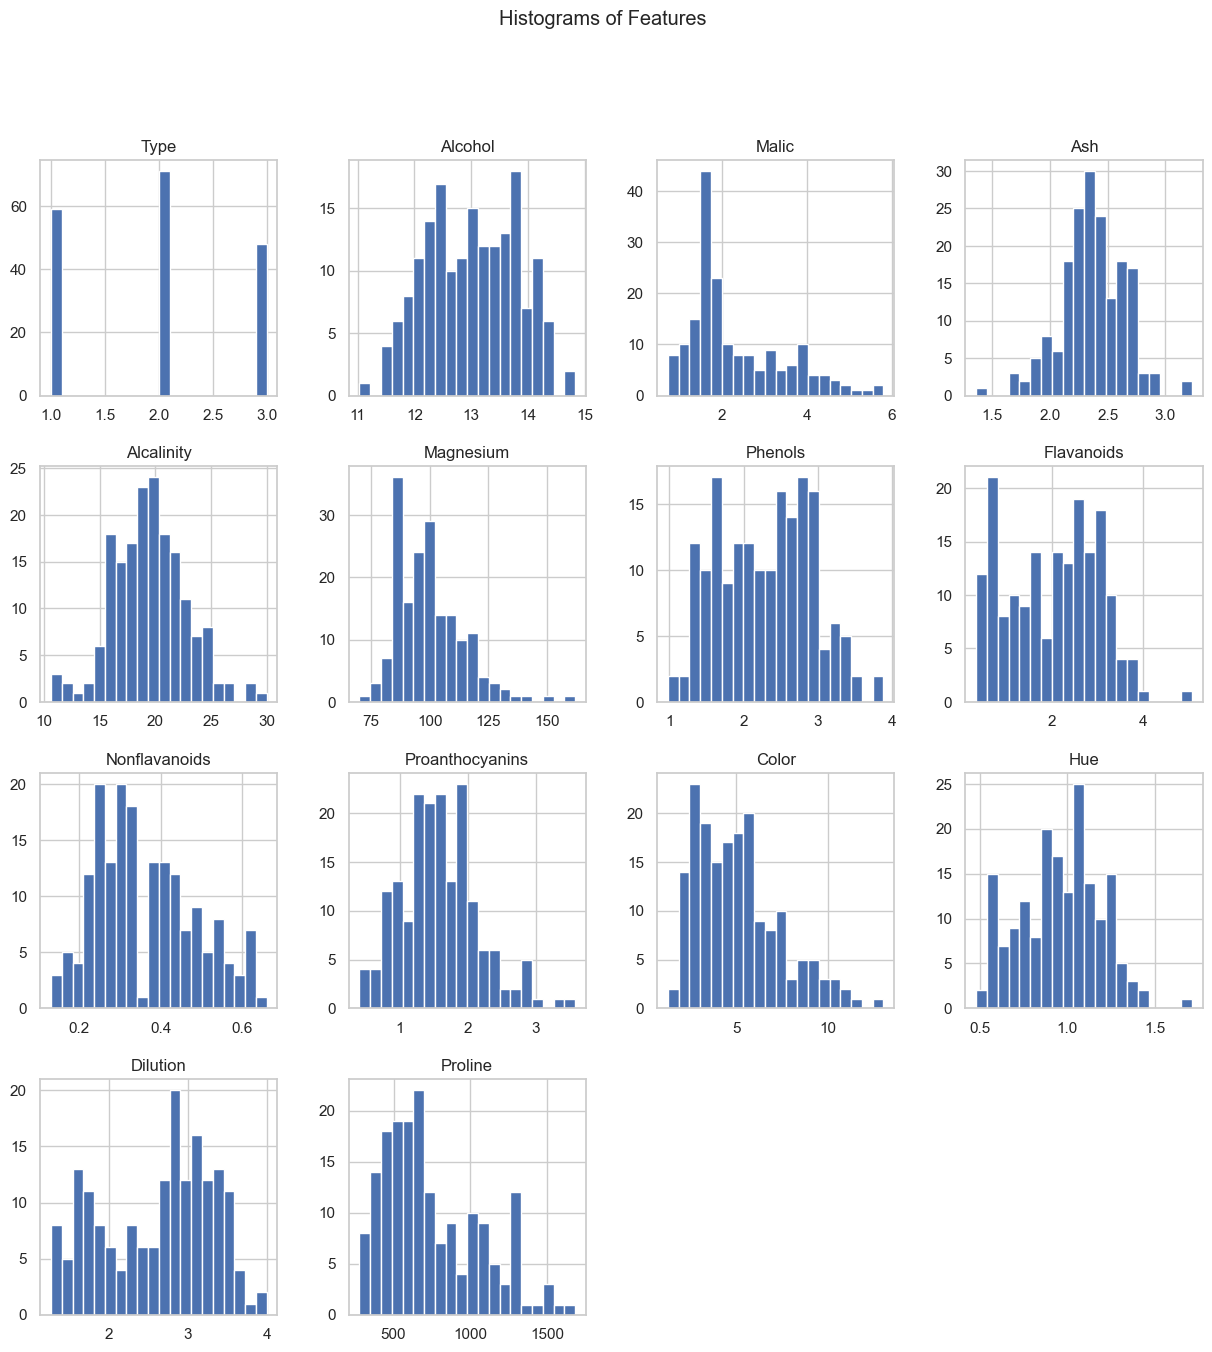

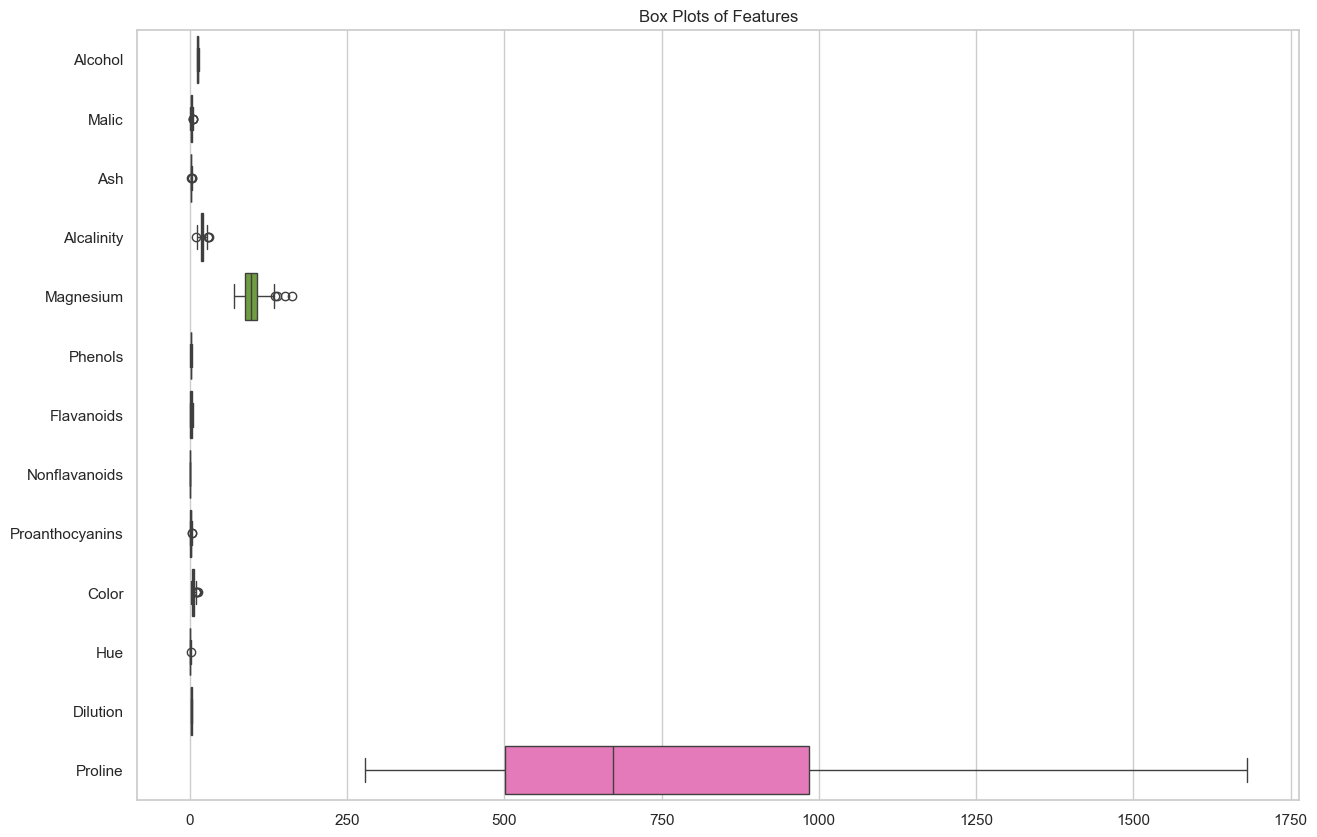

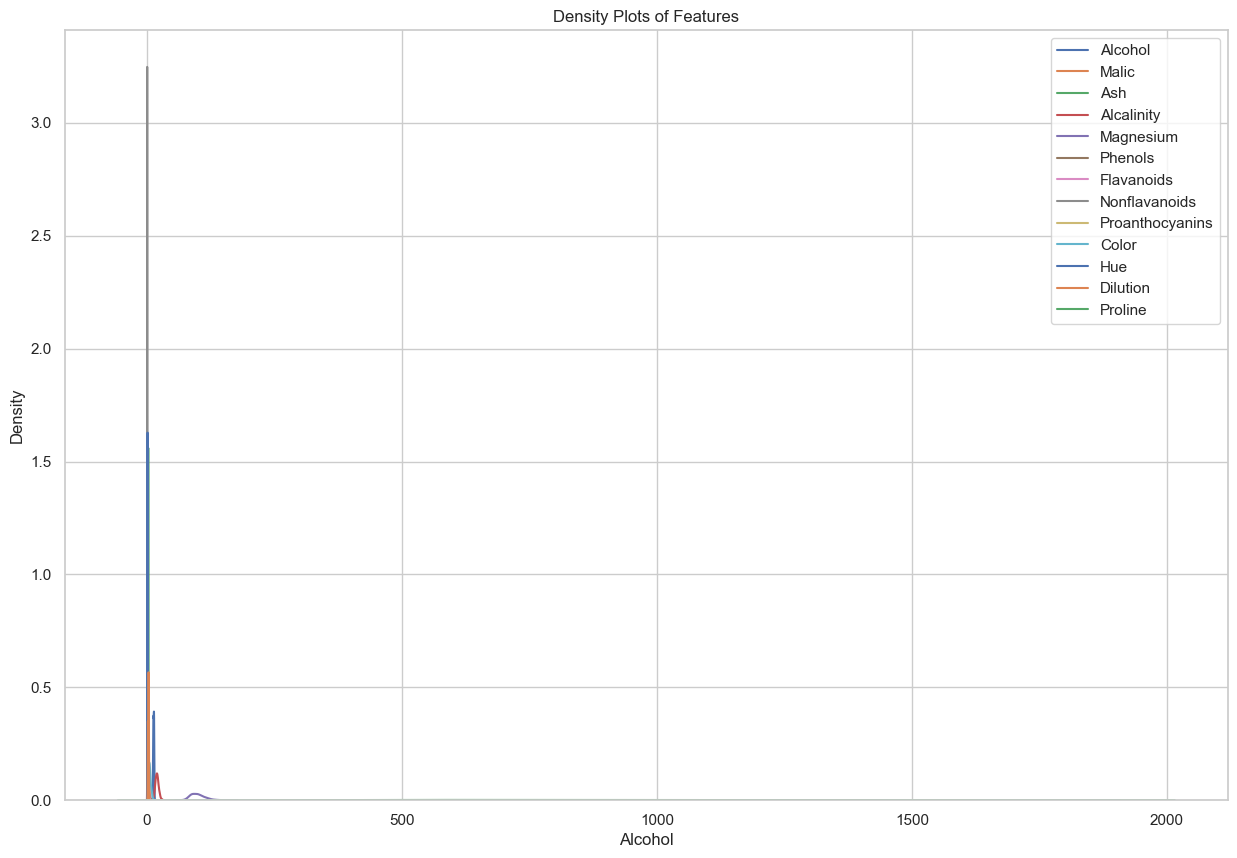

In [4]:
# Step 2: Examine the distribution of features using histograms, box plots, or density plots
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for plots
sns.set(style="whitegrid")

# Plot histograms for all features
df.hist(figsize=(15, 15), bins=20)
plt.suptitle("Histograms of Features")
plt.show()

# Plot box plots for all features
plt.figure(figsize=(15, 10))
sns.boxplot(data=df.drop(columns=['Type']), orient="h")
plt.title("Box Plots of Features")
plt.show()

# Plot density plots for all features
plt.figure(figsize=(15, 10))
for column in df.columns[1:]:  # Skip the 'Type' column
    sns.kdeplot(df[column], label=column)
plt.title("Density Plots of Features")
plt.legend()
plt.show()

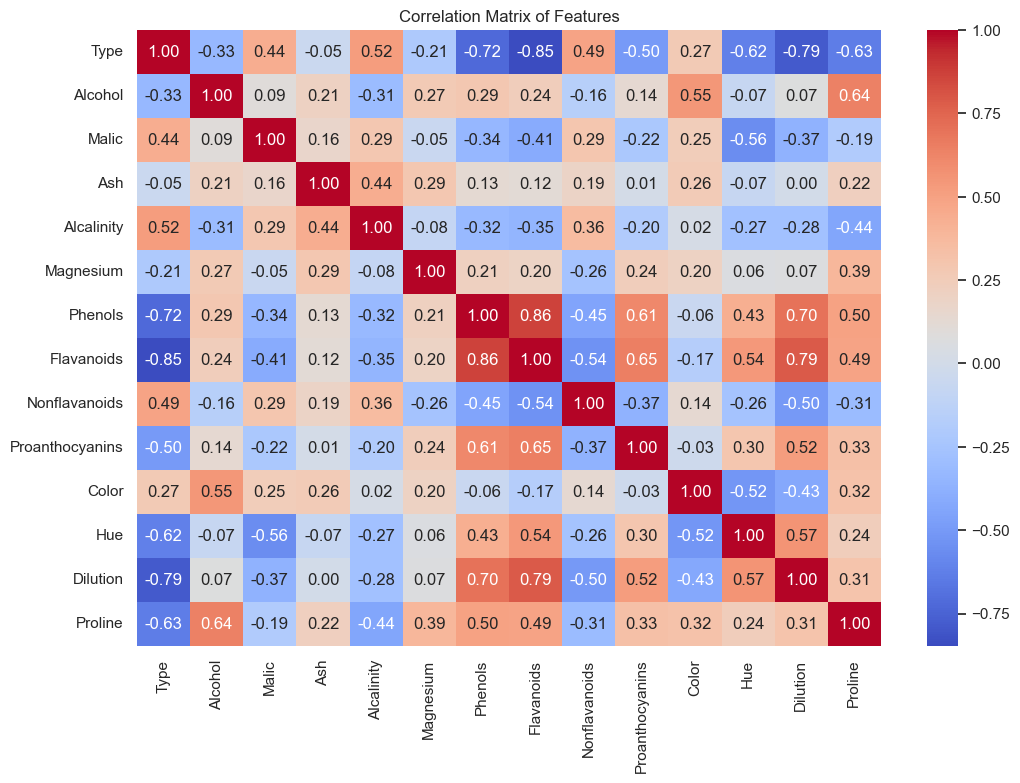

In [5]:
# Step 3: Investigate correlations between features
# Compute the correlation matrix
corr_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Features")
plt.show()

In [6]:
# Step 4: Standardize the features to have a mean of 0 and a standard deviation of 1
from sklearn.preprocessing import StandardScaler

# Separate features and target variable
X = df.drop(columns=['Type'])
y = df['Type']

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled features back to a DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Display the first few rows of the scaled dataset
print("First 5 rows of the scaled dataset:")
print(X_scaled_df.head())

First 5 rows of the scaled dataset:
    Alcohol     Malic       Ash  Alcalinity  Magnesium   Phenols  Flavanoids  \
0  1.518613 -0.562250  0.232053   -1.169593   1.913905  0.808997    1.034819   
1  0.246290 -0.499413 -0.827996   -2.490847   0.018145  0.568648    0.733629   
2  0.196879  0.021231  1.109334   -0.268738   0.088358  0.808997    1.215533   
3  1.691550 -0.346811  0.487926   -0.809251   0.930918  2.491446    1.466525   
4  0.295700  0.227694  1.840403    0.451946   1.281985  0.808997    0.663351   

   Nonflavanoids  Proanthocyanins     Color       Hue  Dilution   Proline  
0      -0.659563         1.224884  0.251717  0.362177  1.847920  1.013009  
1      -0.820719        -0.544721 -0.293321  0.406051  1.113449  0.965242  
2      -0.498407         2.135968  0.269020  0.318304  0.788587  1.395148  
3      -0.981875         1.032155  1.186068 -0.427544  1.184071  2.334574  
4       0.226796         0.401404 -0.319276  0.362177  0.449601 -0.037874  


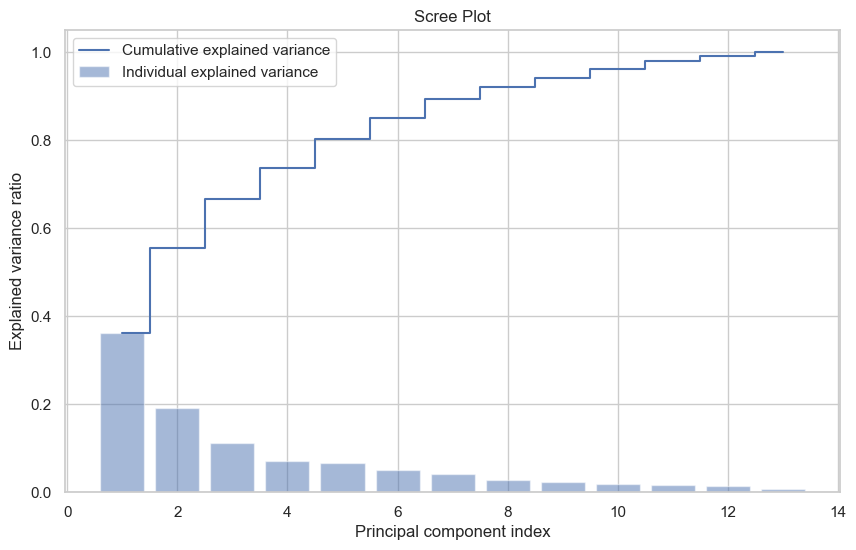

Optimal number of components: 10


In [7]:
# Step 5: Implement PCA and determine the optimal number of components
from sklearn.decomposition import PCA
import numpy as np

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot the explained variance ratio (scree plot)
explained_variance = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(cumulative_explained_variance) + 1), cumulative_explained_variance, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot')
plt.legend(loc='best')
plt.show()

# Determine the optimal number of components (e.g., 95% variance)
optimal_num_components = np.argmax(cumulative_explained_variance >= 0.95) + 1
print(f"Optimal number of components: {optimal_num_components}")

In [8]:
# Step 6: Transform the original dataset into principal components
# Apply PCA with the optimal number of components
pca = PCA(n_components=optimal_num_components)
X_pca = pca.fit_transform(X_scaled)


In [9]:
# convert the PCA components to a DataFrame
X_pca_df = pd.DataFrame(data=X_pca, columns=[f"PC{i+1}" for i in range(optimal_num_components)])

# Display the first few rows of the PCA-transformed dataset
print("First 5 rows of the PCA-transformed dataset:")
X_pca_df.head()

First 5 rows of the PCA-transformed dataset:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,3.316751,1.443463,-0.165739,-0.215631,0.693043,0.223880,0.596427,-0.065139,-0.641443,1.020956
1,2.209465,-0.333393,-2.026457,-0.291358,-0.257655,0.927120,0.053776,-1.024416,0.308847,0.159701
2,2.516740,1.031151,0.982819,0.724902,-0.251033,-0.549276,0.424205,0.344216,1.177834,0.113361
3,3.757066,2.756372,-0.176192,0.567983,-0.311842,-0.114431,-0.383337,-0.643593,-0.052544,0.239413
4,1.008908,0.869831,2.026688,-0.409766,0.298458,0.406520,0.444074,-0.416700,-0.326819,-0.078366


Silhouette Score for original dataset: 0.28


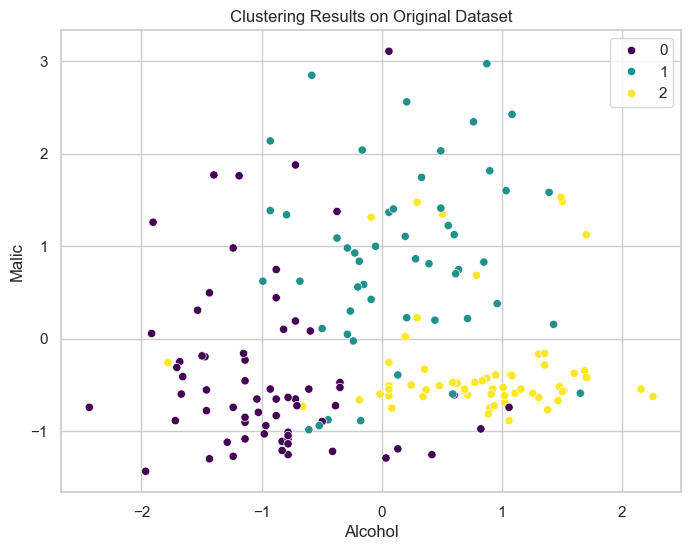

In [10]:
# Step 7: Apply clustering to the original dataset
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Apply K-means clustering to the original dataset
kmeans = KMeans(n_clusters=3, random_state=42)
clusters_original = kmeans.fit_predict(X_scaled)

# Add cluster labels to the original dataset
df['Cluster_Original'] = clusters_original

# Evaluate clustering performance using silhouette score
silhouette_original = silhouette_score(X_scaled, clusters_original)
print(f"Silhouette Score for original dataset: {silhouette_original:.2f}")

# Visualize clustering results (using the first two features for simplicity)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_scaled_df.iloc[:, 0], y=X_scaled_df.iloc[:, 1], hue=clusters_original, palette='viridis')
plt.title("Clustering Results on Original Dataset")
plt.show()

Silhouette Score for PCA-transformed dataset: 0.30


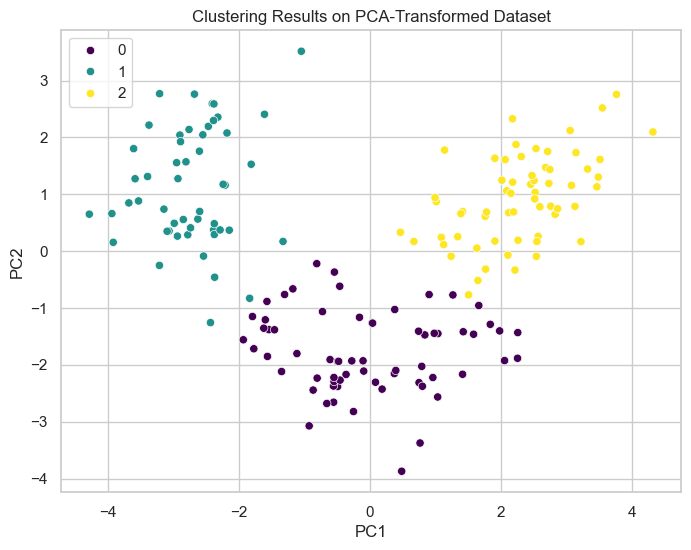

In [12]:
# Step 8: Apply clustering to the PCA-transformed dataset
# Apply K-means clustering to the PCA-transformed dataset
kmeans_pca = KMeans(n_clusters=3, random_state=42)
clusters_pca = kmeans_pca.fit_predict(X_pca)

# Add cluster labels to the PCA-transformed dataset
X_pca_df['Cluster_PCA'] = clusters_pca

# Evaluate clustering performance using silhouette score
silhouette_pca = silhouette_score(X_pca, clusters_pca)
print(f"Silhouette Score for PCA-transformed dataset: {silhouette_pca:.2f}")

# Visualize clustering results (using the first two principal components)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_df.iloc[:, 0], y=X_pca_df.iloc[:, 1], hue=clusters_pca, palette='viridis')
plt.title("Clustering Results on PCA-Transformed Dataset")
plt.show()

In [13]:
# Step 9: Compare clustering results from original and PCA-transformed data
# Compare silhouette scores
print(f"Silhouette Score (Original): {silhouette_original:.2f}")
print(f"Silhouette Score (PCA): {silhouette_pca:.2f}")

# Compare cluster assignments
comparison_df = pd.DataFrame({
    'Original_Cluster': clusters_original,
    'PCA_Cluster': clusters_pca
})
print("\nComparison of cluster assignments:")
print(comparison_df.head())

Silhouette Score (Original): 0.28
Silhouette Score (PCA): 0.30

Comparison of cluster assignments:
   Original_Cluster  PCA_Cluster
0                 2            2
1                 2            2
2                 2            2
3                 2            2
4                 2            2


In [14]:
# Step 10: Summarize key findings and insights
print("Key Findings and Insights:")
print("1. PCA reduced the dimensionality of the dataset while retaining most of the variance.")
print("2. Clustering performance (silhouette score) on the PCA-transformed dataset was comparable to the original dataset.")
print("3. PCA can be useful for reducing computational complexity and improving interpretability in high-dimensional datasets.")
print("4. The choice between using PCA and clustering directly on the original dataset depends on the specific use case and trade-offs between interpretability and performance.")

Key Findings and Insights:
1. PCA reduced the dimensionality of the dataset while retaining most of the variance.
2. Clustering performance (silhouette score) on the PCA-transformed dataset was comparable to the original dataset.
3. PCA can be useful for reducing computational complexity and improving interpretability in high-dimensional datasets.
4. The choice between using PCA and clustering directly on the original dataset depends on the specific use case and trade-offs between interpretability and performance.
